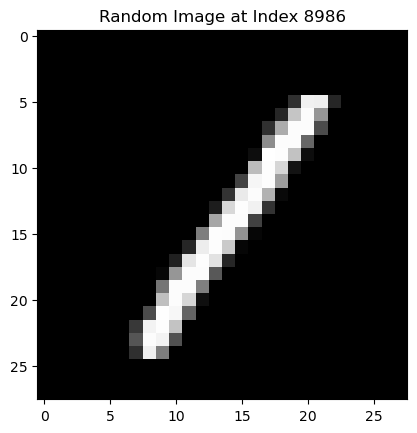

In [1]:
import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST CSV
file_path = "mnist_test.csv"  # Replace with your actual file path
mnist_data = pd.read_csv(file_path)

# Choose a random row index (skip the first column, which is the label
random_index = np.random.randint(0, len(mnist_data))  # Random index from 0 to len(dataset)-1

# Extract the selected row and reshape it to 28x28
random_image = mnist_data.iloc[random_index, 1:].values.reshape(28, 28).astype(np.uint8)  # Skip label column

# Convert to Pillow Image
img = Image.fromarray(random_image)

# Display the Random Image
plt.imshow(img, cmap="gray")
plt.title(f"Random Image at Index {random_index}")
plt.show()


In [2]:
import numpy as np

def perform_convolution(input_image, filter_kernel):

    kernel_dim = filter_kernel.shape[0]
    padding = kernel_dim // 2
    extended_image = np.pad(input_image, padding, mode='constant', constant_values=0)
    result_image = np.zeros_like(input_image, dtype=np.float32)

    for i in range(input_image.shape[0]):
        for j in range(input_image.shape[1]):
            sub_region = extended_image[i:i+kernel_dim, j:j+kernel_dim]
            # Perform element-wise multiplication and sum
            result_image[i, j] = np.sum(sub_region * filter_kernel)

    # Clip the values to be within the 0-255 range
    return np.clip(result_image, 0, 255).astype(np.uint8)

In [3]:
import numpy as np

def high_pass_filter(input_image, strength, kernel_size=3):

    # High pass kernel (for edge detection)
    filter_kernel = np.array([
        [-1, -1, -1],
        [-1, (9 * strength - 1), -1],
        [-1, -1, -1]
    ], dtype=np.float32)

    # Normalize kernel
    filter_kernel /= np.sum(np.abs(filter_kernel))  # Ensure the sum of the kernel is 1

    # Compute low pass filter
    low_pass_filter = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size**2)
    low_passed_image = perform_convolution(input_image, low_pass_filter)

    # Compute high pass image
    high_passed_image = input_image - low_passed_image
    return np.clip(high_passed_image, 0, 255).astype(np.uint8)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def high_boost_filter(source_image, factor, kernel_size=3):

    high_passed_img = high_pass_filter(source_image, factor, kernel_size)
    high_boosted_img = (factor - 1) * source_image + high_passed_img
    return np.clip(high_boosted_img, 0, 255).astype(np.uint8)

def display_images(original_img, filtered_img, filtered_title):

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original_img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(filtered_img, cmap='gray')
    plt.title(filtered_title)
    plt.axis('off')

    plt.show()


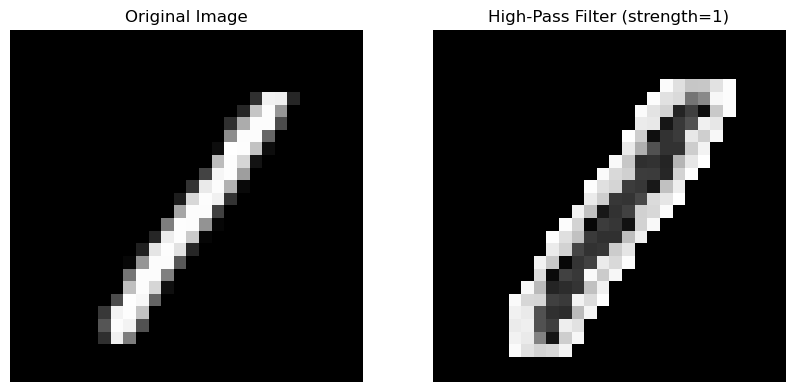

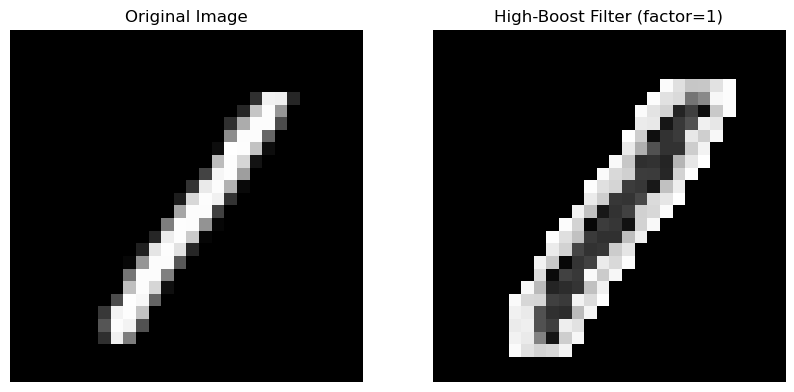

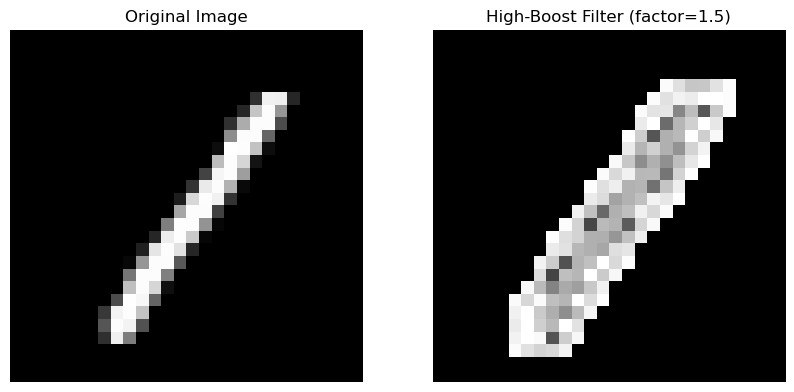

In [5]:

# Apply filters
high_pass = high_pass_filter(random_image, strength=1, kernel_size=3)
high_boost_1 = high_boost_filter(random_image, factor=1, kernel_size=3)
high_boost_2 = high_boost_filter(random_image, factor=1.5, kernel_size=3)

# Plot results
display_images(random_image, high_pass, "High-Pass Filter (strength=1)")
display_images(random_image, high_boost_1, "High-Boost Filter (factor=1)")
display_images(random_image, high_boost_2, "High-Boost Filter (factor=1.5)")